In [1]:
# 라이브러리 로딩
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


# 디바이스 준비
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [2]:
# 데이터 로더 함수
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor


In [3]:
# 학습 함수
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0


    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss


        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()


In [4]:
# 검증 함수
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산


    return eval_loss, pred


In [5]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()


In [6]:
from torchvision import datasets
from torchvision.transforms import ToTensor


train_dataset = datasets.FashionMNIST(root='data', train=True, download=True,
transform=ToTensor())
test_dataset = datasets.FashionMNIST(root='data', train=False, download=True,
transform=ToTensor())


100.0%


Extracting data\FashionMNIST\raw\train-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%

Extracting data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data\FashionMNIST\raw



In [7]:
class_list = train_dataset.classes
class_list


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

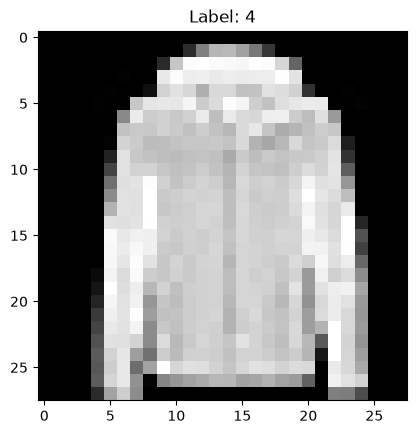

In [8]:
n = 5000
image, label = train_dataset.data[n], train_dataset.targets[n]


# 이미지 시각화
plt.imshow(image, cmap='gray')
plt.title(f'Label: {label}')
plt.show()


In [9]:
x_train = train_dataset.data / 255
y_train = train_dataset.targets
x_test = test_dataset.data / 255
y_test = test_dataset.targets


In [10]:
x_train = x_train[:20000]
y_train = y_train[:20000]
print(x_train.shape)


torch.Size([20000, 28, 28])


In [11]:
x_val, x_test = x_test[:5000], x_test[5000:]
y_val, y_test = y_test[:5000], y_test[5000:]
print(x_val.shape, x_test.shape)


torch.Size([5000, 28, 28]) torch.Size([5000, 28, 28])


In [12]:
x_train = x_train.view(20000, 1, 28, 28)    # 3차원
x_val = x_val.view(5000, 1, 28, 28)         # 4차원(장수, 채널, 폭, 넓이). 채널: 색
x_test = x_test.view(5000, 1, 28, 28)

In [13]:
train_TensorDS = TensorDataset(x_train, y_train)
batch_size = 64
train_loader = DataLoader(train_TensorDS, batch_size=batch_size)


In [14]:
n_feature = 28 * 28
n_class = 10
# 모델 구조 설계
model = nn.Sequential(nn.Flatten(),
        nn.Linear(n_feature, 512), nn.ReLU(),
        nn.Linear(512, 256), nn.ReLU(),
        nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, 64), nn.ReLU(),
        nn.Linear(64, n_class)
        ).to(device)


In [15]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)


In [16]:
from torchsummary import summary
summary(model, input_size = (n_feature,))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
            Linear-4                  [-1, 256]         131,328
              ReLU-5                  [-1, 256]               0
            Linear-6                  [-1, 256]          65,792
              ReLU-7                  [-1, 256]               0
            Linear-8                   [-1, 64]          16,448
              ReLU-9                   [-1, 64]               0
           Linear-10                   [-1, 10]             650
Total params: 616,138
Trainable params: 616,138
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 2.35
Estimated T

Epoch 1, train loss : 0.7477, val loss : 0.5313
Epoch 2, train loss : 0.4664, val loss : 0.5006
Epoch 3, train loss : 0.4055, val loss : 0.4461
Epoch 4, train loss : 0.3718, val loss : 0.4280
Epoch 5, train loss : 0.3487, val loss : 0.4288
Epoch 6, train loss : 0.3245, val loss : 0.4402
Epoch 7, train loss : 0.3039, val loss : 0.4412
Epoch 8, train loss : 0.2831, val loss : 0.4456
Epoch 9, train loss : 0.2751, val loss : 0.4300
Epoch 10, train loss : 0.2606, val loss : 0.4608
Epoch 11, train loss : 0.2456, val loss : 0.4797
Epoch 12, train loss : 0.2381, val loss : 0.4543
Epoch 13, train loss : 0.2320, val loss : 0.4654
Epoch 14, train loss : 0.2154, val loss : 0.4702
Epoch 15, train loss : 0.2062, val loss : 0.4982
Epoch 16, train loss : 0.2029, val loss : 0.4873
Epoch 17, train loss : 0.1918, val loss : 0.5004
Epoch 18, train loss : 0.1834, val loss : 0.5167
Epoch 19, train loss : 0.1875, val loss : 0.4686
Epoch 20, train loss : 0.1839, val loss : 0.4933
Epoch 21, train loss : 0.1715

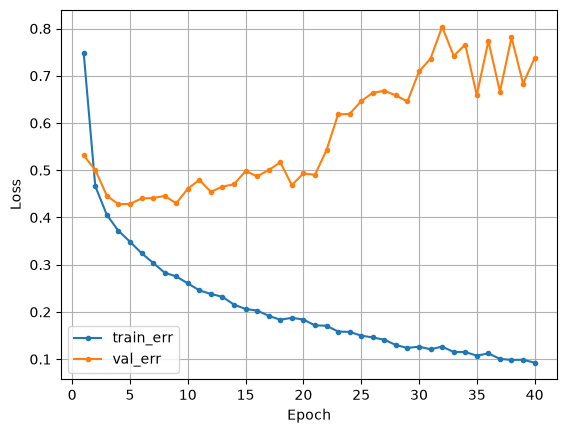

In [ ]:
epochs = 40
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)
    # 리스트에 추가
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)

# val 상승. 과적합 상태
# 만약 train loss가 상승하면 과소적합 상태.

In [ ]:
# 조기종료(원래 개선하기 위한 목적이 아니라 조기종료보다 드롭아웃, 규제 등 다른 방법 먼저 고려해 봐야 함.)
n_class = 10
model1= nn.Sequential(nn.Flatten(),
            nn.Linear(n_feature, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, n_class)
            ).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.001)


# 1. 조기 종료를 위한 변수 설정 ----------------
patience = 5        # 5번 동안 오차가 줄어들지(개선되지) 않으면 종료.
best_loss = float('inf')
counter = 0
tr_loss_list, val_loss_list = [], []
for t in range(40):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model1, loss_fn, device)
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)  # 최댓값
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


    # 2. 조기 종료 확인 -------------------
    if val_loss > best_loss:    # 개선x: 오차가 줄지 않았다.
        counter += 1
        print(f'--> status, best_loss : {best_loss:4f}, counter : {counter}')
    else:                       # 개선: 오차가 줄었다.
        best_loss = val_loss
        counter = 0
    # 3. 조기 종료 조건 확인 --------------------
    if counter >= patience:
        print('Early Stopping!')
        break


Epoch 1, train loss : 0.7461, val loss : 0.5905
Epoch 2, train loss : 0.4741, val loss : 0.5080
Epoch 3, train loss : 0.4160, val loss : 0.4618
Epoch 4, train loss : 0.3751, val loss : 0.4494
Epoch 5, train loss : 0.3469, val loss : 0.4483
Epoch 6, train loss : 0.3297, val loss : 0.4471
Epoch 7, train loss : 0.3067, val loss : 0.4236
Epoch 8, train loss : 0.2917, val loss : 0.4386
--> status, best_loss : 0.423604, counter : 1
Epoch 9, train loss : 0.2747, val loss : 0.4248
--> status, best_loss : 0.423604, counter : 2
Epoch 10, train loss : 0.2592, val loss : 0.4353
--> status, best_loss : 0.423604, counter : 3
Epoch 11, train loss : 0.2544, val loss : 0.4840
--> status, best_loss : 0.423604, counter : 4
Epoch 12, train loss : 0.2505, val loss : 0.4496
--> status, best_loss : 0.423604, counter : 5
Early Stopping!


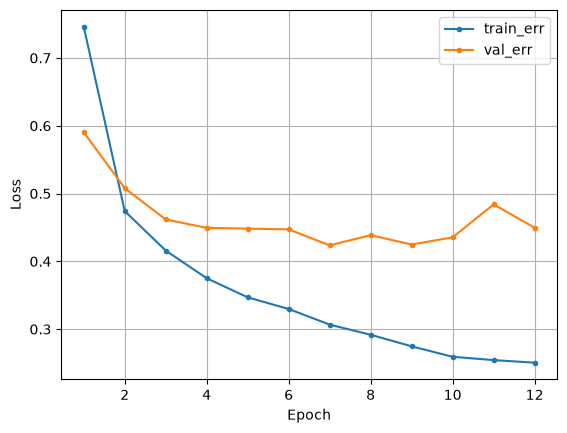

In [19]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [20]:
# 드롭아웃
n_feature = 28 * 28
n_class = 10
dropout_rate = 0.4


model2 = nn.Sequential(nn.Flatten(),
            nn.Linear(n_feature, 512), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, n_class)
            ).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)


Epoch 1, train loss : 1.0698, val loss : 0.6398
Epoch 2, train loss : 0.6452, val loss : 0.5268
Epoch 3, train loss : 0.5537, val loss : 0.4826
Epoch 4, train loss : 0.5138, val loss : 0.4490
Epoch 5, train loss : 0.4909, val loss : 0.4312
Epoch 6, train loss : 0.4652, val loss : 0.4326
Epoch 7, train loss : 0.4452, val loss : 0.4269
Epoch 8, train loss : 0.4341, val loss : 0.4123
Epoch 9, train loss : 0.4201, val loss : 0.4233
Epoch 10, train loss : 0.4184, val loss : 0.4097
Epoch 11, train loss : 0.4102, val loss : 0.4040
Epoch 12, train loss : 0.3995, val loss : 0.4018
Epoch 13, train loss : 0.3925, val loss : 0.3990
Epoch 14, train loss : 0.3906, val loss : 0.4124
Epoch 15, train loss : 0.3715, val loss : 0.4146
Epoch 16, train loss : 0.3697, val loss : 0.4136
Epoch 17, train loss : 0.3635, val loss : 0.3992
Epoch 18, train loss : 0.3627, val loss : 0.4152
Epoch 19, train loss : 0.3575, val loss : 0.4110
Epoch 20, train loss : 0.3532, val loss : 0.4082
Epoch 21, train loss : 0.3489

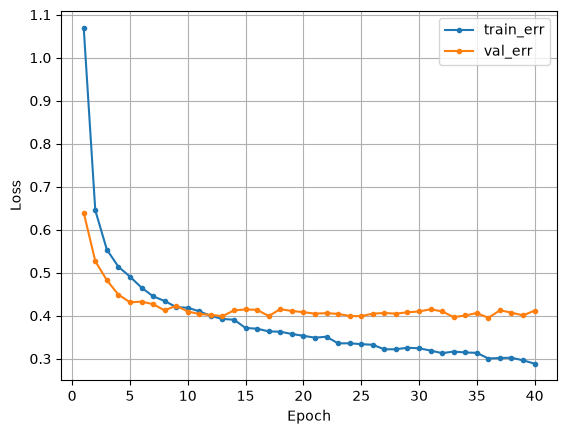

In [21]:
epochs = 40
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model2, loss_fn, device)
    # 리스트에 추가
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


dl_learning_curve(tr_loss_list, val_loss_list)


In [22]:
# 가중치 규제
n_feature = 28 * 28
n_class = 10


model3 = nn.Sequential(nn.Flatten(),
            nn.Linear(n_feature, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, n_class)
            ).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001, weight_decay = 0.001)


Epoch 1, train loss : 0.7930, val loss : 0.6063
Epoch 2, train loss : 0.5126, val loss : 0.5639
Epoch 3, train loss : 0.4578, val loss : 0.5003
Epoch 4, train loss : 0.4280, val loss : 0.4554
Epoch 5, train loss : 0.4050, val loss : 0.4466
Epoch 6, train loss : 0.3878, val loss : 0.4408
Epoch 7, train loss : 0.3703, val loss : 0.4215
Epoch 8, train loss : 0.3550, val loss : 0.4297
Epoch 9, train loss : 0.3458, val loss : 0.4525
Epoch 10, train loss : 0.3332, val loss : 0.4239
Epoch 11, train loss : 0.3222, val loss : 0.4706
Epoch 12, train loss : 0.3171, val loss : 0.4735
Epoch 13, train loss : 0.3056, val loss : 0.4470
Epoch 14, train loss : 0.2979, val loss : 0.4323
Epoch 15, train loss : 0.2944, val loss : 0.4490
Epoch 16, train loss : 0.2906, val loss : 0.4551
Epoch 17, train loss : 0.2873, val loss : 0.4761
Epoch 18, train loss : 0.2781, val loss : 0.5032
Epoch 19, train loss : 0.2711, val loss : 0.4882
Epoch 20, train loss : 0.2625, val loss : 0.4856
Epoch 21, train loss : 0.2663

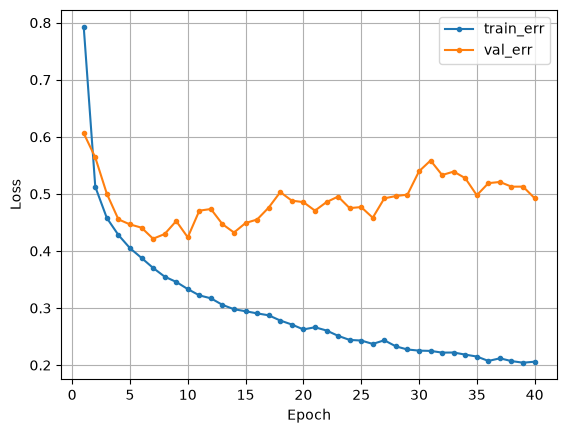

In [23]:
epochs = 40
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model3, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model3, loss_fn, device)
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


dl_learning_curve(tr_loss_list, val_loss_list)
